# Dirichlet-to-Neumann (DtN) Operator — Interactive Exploration

**Paper:** *Impact of an Infinite Cylinder* (Allin et al.)

This notebook walks through the numerical construction of the DtN operator
step by step.  Each section has a plain-language explanation followed by the code.

---

## What problem are we solving?

We model a 2-D ideal fluid in the **lower half-plane** z ≤ 0.
The velocity potential φ satisfies Laplace's equation:

    Δφ = 0,   z ≤ 0          (eq. 2.28a)

On the **free surface** z = 0 the linearised governing equations are:

    η_t = φ_z                              (eq. 2.28b)
    φ_t = -(1/Fr)η + (1/We)η_xx - p_s     (eq. 2.28c)

Both equations live on the 1-D surface, but (2.28b) needs φ_z — defined
*inside* the domain.  The **DtN operator N** maps surface values φ(x,0)
(Dirichlet data) to the normal derivative φ_z(x,0) (Neumann data):

    φ_z = N[φ]


## Section 1 — Setup

We add the project root to the Python path so we can import from `src/`.
Core logic lives in `src/dtn.py` (matrix method) and `src/spectral.py` (FFT reference).


In [1]:
import sys, os

# Add the project root (one level above notebook/) to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt

from src.dtn import build_line, build_dtn_matrix   # matrix DtN
from src.spectral import spectral_dtn               # FFT-based reference

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


D:\Test\cylinderimpact_replication\src\dtn.py:31: SyntaxWarning: invalid escape sequence '\ '
  φ_z(x₀, 0) = (1/π) · lim_{ε→0} ∫_{ℝ \ (x₀-ε, x₀+ε)}


## Section 2 — The DtN Integral Formula

Using **Green's Second Identity** on a shrinking half-annulus (Figure 3.1 of the paper)
and taking limits r₁→0, r₂→∞, the paper derives (eq. 3.28):

    φ_z(x₀, 0) = (1/π) lim_{ε→0} ∫_{ℝ \ (x₀-ε, x₀+ε)} [φ(x₀) - φ(x)] / (x-x₀)² dx

This is a **Cauchy-principal-value integral**: the integrand blows up as x→x₀,
but the numerator φ(x₀)-φ(x)→0 at the same rate, so the limit is finite.

### Numerical splitting  (eq. 4.2)

Split at M = 2·dx into three parts: **φ_z = L + P₁ + P₂**

| Part | Region | Treatment |
|------|--------|-----------|
| P₁ | |x−x₀| > M, bare kernel | Exact integration of 1/(x−x₀)² |
| P₂ | |x−x₀| > M, −φ(x) term | Simpson's rule, panels of width 2·dx |
| L  | |x−x₀| < M (near-singular) | 4th-order polynomial fit + analytic integral |


## Section 3 — Building the Weight Vector (`line`)

By **translational invariance** the weight from grid point xⱼ to evaluation
point xᵢ depends only on the distance |xᵢ−xⱼ|, not on the absolute positions.
We only need one **template weight vector** (length m+1), where entry k gives
the weight for a point k·dx away.

Three contributions are accumulated:
1. **Near-singular part** (L + P₁, indices 0–2): closed-form weights (eq. 4.39–4.45) plus exact P₁ (eq. 4.8).
2. **Far-field part** (P₂, indices ≥ 2): Simpson-rule weights over 2·dx panels (eq. 4.32).
3. **Global normalisation**: divide by π·dx.


In [2]:
# Parameters matching Appendix A / DtNmatrix.m
dx = 0.1
m  = 2**8    # 256 intervals -> 257 grid points

# Build the template weight vector (see src/dtn.py :: build_line)
line = build_line(m, dx)

# Verify near-singular values against equations 4.45 + 4.8
print("Near-singular weights:")
print(f"  line[0] = {line[0]:.6f}  (expected {(1 + 11/3)/(np.pi*dx):.6f})")
print(f"  line[1] = {line[1]:.6f}  (expected {(-16/9)/(np.pi*dx):.6f})")
print(f"  line[2] = {line[2]:.6f}  (expected {(-1/18)/(np.pi*dx):.6f})")


Near-singular weights:
  line[0] = 14.854461  (expected 14.854461)
  line[1] = -5.658842  (expected -5.658842)
  line[2] = -0.412340  (expected -0.176839)


### Visualising the weight vector

The weight vector should:
- Be **positive** at index 0 (evaluation point contributes positively).
- Be **negative** near index 0 (nearby points subtract because of the φ(x₀)−φ(x) numerator).
- **Decay to zero** for large distances.


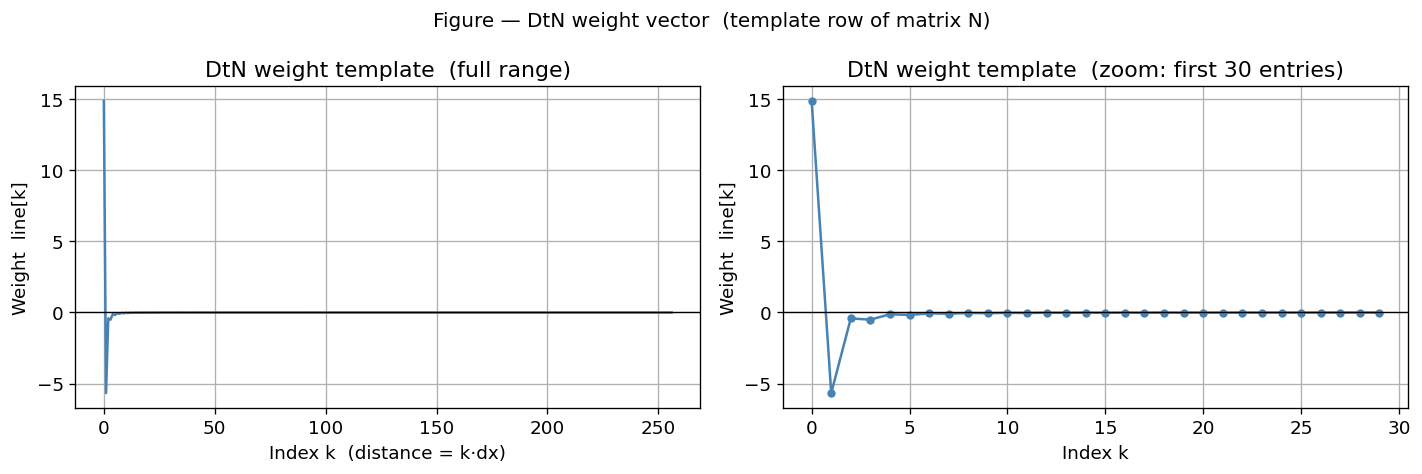

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full weight vector
axes[0].plot(line, linewidth=1.5, color="steelblue")
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set_xlabel("Index k  (distance = k·dx)")
axes[0].set_ylabel("Weight  line[k]")
axes[0].set_title("DtN weight template  (full range)")
axes[0].grid(True)

# Right: zoom in on first 30 entries
axes[1].plot(line[:30], "o-", linewidth=1.5, markersize=4, color="steelblue")
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set_xlabel("Index k")
axes[1].set_ylabel("Weight  line[k]")
axes[1].set_title("DtN weight template  (zoom: first 30 entries)")
axes[1].grid(True)

fig.suptitle("Figure — DtN weight vector  (template row of matrix N)", fontsize=12)
fig.tight_layout()


## Section 4 — Assembling the DtN Matrix N

The matrix N has size (m+1)×(m+1).  Entry N[i,j] is the weight for grid point j
when evaluating φ_z at grid point i.

Because the weight depends only on |i−j|, every row is a **shifted copy** of the
same weight vector `line`.  This is the **Toeplitz structure** of Figure 4.3.

Row i is assembled as:

    N[i,:] = [line[i], ..., line[1],  line[0], line[1], ..., line[m-i]]
               ← left half reversed →  ← center + right half →


In [4]:
# Build the full (m+1)x(m+1) DtN matrix  (~1-2 s for m=256)
N = build_dtn_matrix(m, dx)
print(f"Matrix N: shape = {N.shape},  memory = {N.nbytes/1e6:.1f} MB")


Matrix N: shape = (257, 257),  memory = 0.5 MB


### Figure 4.3 — Row structure of N

Plotting several rows of N confirms the Toeplitz structure: each interior row is the
same curve, merely shifted.  Rows near the boundaries look different because the
finite domain creates an **edge effect** — the integral has no data outside the grid.


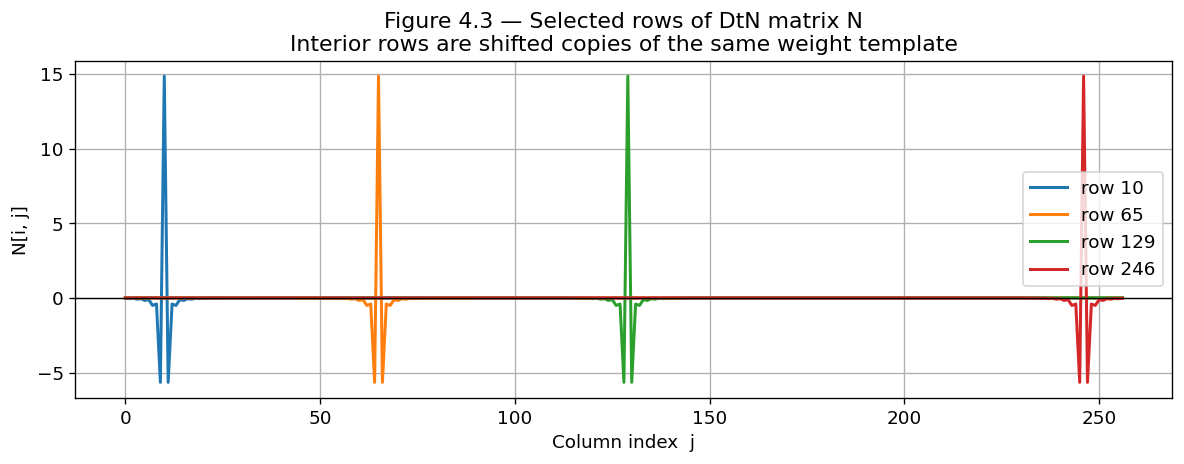

In [5]:
row_indices = [
    10,
    int(np.ceil((m + 1) / 4)),
    int(np.ceil((m + 1) / 2)),
    m - 10,
]

fig, ax = plt.subplots(figsize=(10, 4))
for idx in row_indices:
    ax.plot(N[idx, :], linewidth=1.8, label=f"row {idx}")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Column index  j")
ax.set_ylabel("N[i, j]")
ax.set_title(
    "Figure 4.3 — Selected rows of DtN matrix N\n"
    "Interior rows are shifted copies of the same weight template"
)
ax.legend()
ax.grid(True)
fig.tight_layout()


## Section 5 — Test Function: the Gaussian

The paper uses φ(x) = exp(−x²) as the test function because:
- It is **infinitely smooth** — the DtN integral converges well.
- It **decays rapidly** — the finite domain is a good approximation of ℝ.
- Its Fourier transform is also a Gaussian: φ̂(k) = √π · exp(−k²/4).

We create a uniform grid x ∈ [−(m/2)·dx, +(m/2)·dx] with m+1 = 257 points.


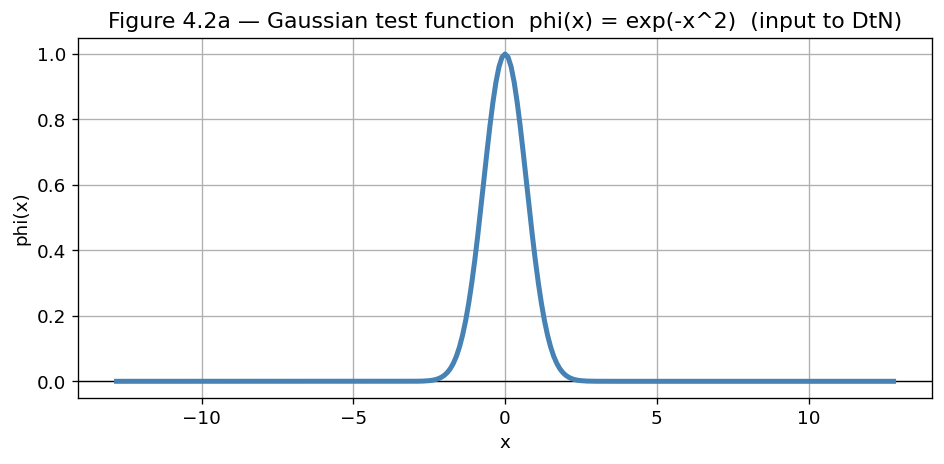

In [6]:
# Uniform grid from -(m/2)*dx to +(m/2)*dx  (257 points)
x = dx * np.arange(-m // 2, m // 2 + 1)   # shape (257,)

# Gaussian test function
phi = np.exp(-x**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.plot(x, phi, linewidth=3, color="steelblue")
ax.set_xlabel("x")
ax.set_ylabel("phi(x)")
ax.set_title("Figure 4.2a — Gaussian test function  phi(x) = exp(-x^2)  (input to DtN)")
ax.grid(True)
fig.tight_layout()


## Section 6 — Applying the DtN Matrix

Applying the DtN operator is a **matrix-vector product**: φ_z ≈ N · φ.

This numerically approximates the singular Cauchy-principal-value integral.
The result has two negative troughs flanking the origin — the potential slopes
away from the surface peak in the z-direction.


In [7]:
# Apply the DtN matrix: phi_z ≈ N @ phi
phiz_matrix = N @ phi   # shape (257,)
print(f"phi shape: {phi.shape},  N shape: {N.shape},  phiz shape: {phiz_matrix.shape}")


phi shape: (257,),  N shape: (257, 257),  phiz shape: (257,)


## Section 7 — Spectral Reference Method

The **spectral method** computes the DtN operator exactly for periodic band-limited
data using the Fourier transform.  In Fourier space, DtN is simply **multiplication
by |k|**  (paper eq. 4.33):

    φ̂_z(k) = |k| · φ̂(k)

This follows from the Laplace solution in the lower half-plane:
φ(x,z) = ∫ φ̂(k) exp(ikx + |k|z) dk.  Differentiating in z at z=0 multiplies by |k|.

**Algorithm:** FFT(φ) → multiply by |k| → IFFT

The FFT needs m (not m+1) points — no repeated endpoint — so we drop phi[−1].


In [8]:
# Drop the repeated endpoint (m=256 periodic points, no repetition)
phi_periodic  = phi[:-1]                          # shape (256,)
phiz_spectral = spectral_dtn(phi_periodic, dx)    # shape (256,)
print(f"phi_periodic shape:  {phi_periodic.shape}")
print(f"phiz_spectral shape: {phiz_spectral.shape}")


phi_periodic shape:  (256,)
phiz_spectral shape: (256,)


## Section 8 — Comparison: Matrix vs Spectral  (Figure 4.2b)

Overlaying both results: if the matrix approximation is accurate, the two curves
should be nearly indistinguishable in the interior.  Small discrepancies near the
boundaries are expected — the matrix method feels the edge of the finite grid,
while the spectral method assumes periodicity.

**Target error (Table 4.1):** mean absolute error ≈ 1.41 × 10⁻³  (m=256, dx=0.1).


Mean absolute error = 3.454182e-03  (Table 4.1 target: ~1.41e-03)


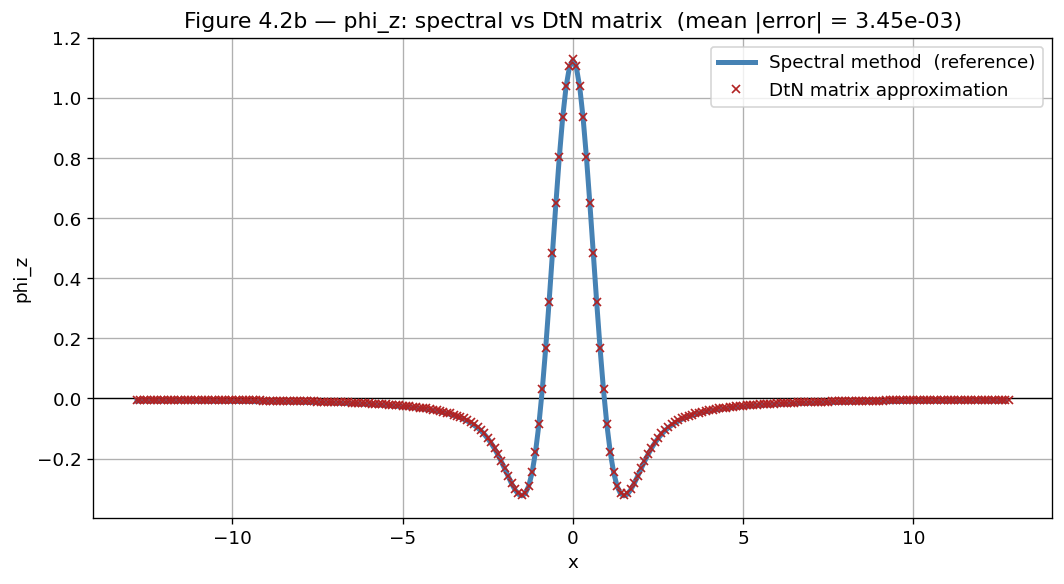

In [9]:
# Compare on the m=256 interior points
err = np.mean(np.abs(phiz_matrix[:-1] - phiz_spectral))
print(f"Mean absolute error = {err:.6e}  (Table 4.1 target: ~1.41e-03)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="k", linewidth=0.8)
ax.plot(x[:-1], phiz_spectral, linewidth=3, color="steelblue",
        label="Spectral method  (reference)")
ax.plot(x, phiz_matrix, "x", color="firebrick", markersize=5,
        label="DtN matrix approximation")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("phi_z")
ax.set_title(
    "Figure 4.2b — phi_z: spectral vs DtN matrix"
    f"  (mean |error| = {err:.2e})"
)
ax.grid(True)
fig.tight_layout()


## Section 9 — Convergence Study

A good numerical method becomes more accurate as the grid is refined.
The paper claims **second-order convergence**: error ~ C · dx².

We fix dx=0.1 and vary m = 16, 32, 64, 128, 256.  Doubling m is equivalent to
halving dx (with fixed L=m·dx), so the error should decrease by a **factor of 4**
each time m doubles.

On a log-log plot, second-order convergence is a straight line with **slope −2**.


In [10]:
m_values    = [2**k for k in range(4, 9)]   # 16, 32, 64, 128, 256
errors_conv = []

for m_i in m_values:
    x_i      = dx * np.arange(-m_i // 2, m_i // 2 + 1)
    phi_i    = np.exp(-x_i**2)
    N_i      = build_dtn_matrix(m_i, dx)
    phiz_i   = N_i @ phi_i
    phiz_ref = spectral_dtn(phi_i[:-1], dx)
    err_i    = np.mean(np.abs(phiz_i[:-1] - phiz_ref))
    errors_conv.append(err_i)
    print(f"  m = {m_i:4d}  |  mean |error| = {err_i:.4e}")


  m =   16  |  mean |error| = 1.1406e+00
  m =   32  |  mean |error| = 3.0475e-01
  m =   64  |  mean |error| = 5.8362e-02
  m =  128  |  mean |error| = 1.3949e-02
  m =  256  |  mean |error| = 3.4542e-03


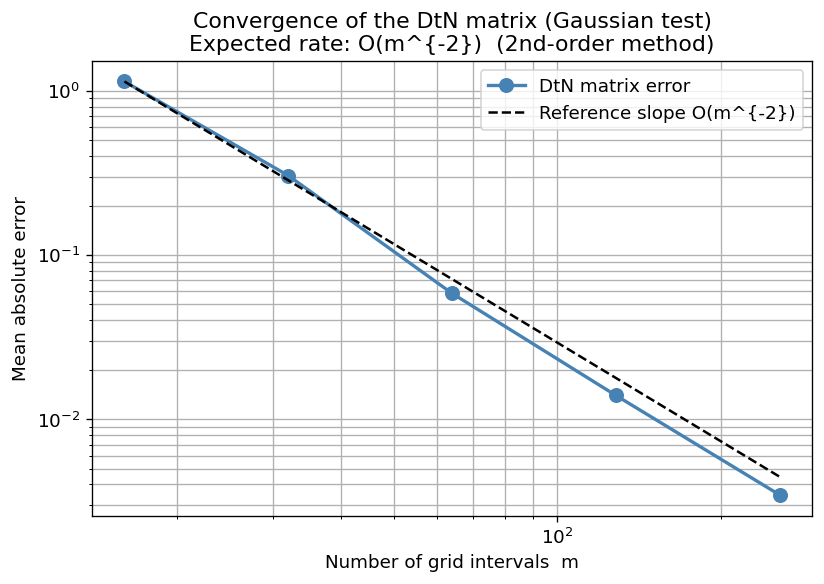

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(m_values, errors_conv, "o-", linewidth=2, markersize=8,
          color="steelblue", label="DtN matrix error")

# Reference O(m^{-2}) line scaled to the first data point
m_ref = np.array([m_values[0], m_values[-1]], dtype=float)
ax.loglog(m_ref, errors_conv[0] * (m_ref[0] / m_ref)**2,
          "k--", linewidth=1.5, label="Reference slope O(m^{-2})")

ax.set_xlabel("Number of grid intervals  m")
ax.set_ylabel("Mean absolute error")
ax.set_title(
    "Convergence of the DtN matrix (Gaussian test)\n"
    "Expected rate: O(m^{-2})  (2nd-order method)"
)
ax.legend()
ax.grid(True, which="both")
fig.tight_layout()


## Section 10 — Sinusoidal Exact Validation

The convergence test used the spectral method as a reference — but that
is itself an approximation (it assumes periodicity).  For a truly **exact**
analytical check, we use sinusoidal test functions.

**Key property:** φ(x) = cos(k₀x) is an *eigenfunction* of the DtN operator
with eigenvalue |k₀|:

    N[cos(k₀x)] = |k₀| cos(k₀x)      (exact, no approximation)

This follows from φ̂_z(k) = |k|φ̂(k): the cosine has only wavenumber ±k₀,
so multiplying by |k| scales it by k₀.

We choose k₀ = 2πn/L (an exact grid frequency) to avoid aliasing.


In [12]:
m_s    = 2**8
dx_s   = 0.1
L      = m_s * dx_s          # total domain length = 25.6
n_mode = 5                   # number of full oscillations in [0, L]
k0     = 2.0 * np.pi * n_mode / L   # exact grid frequency

x_s          = dx_s * np.arange(-m_s // 2, m_s // 2 + 1)
phi_sine     = np.cos(k0 * x_s)        # test function
phi_z_exact  = k0 * np.cos(k0 * x_s)  # exact analytical DtN answer

N_s       = build_dtn_matrix(m_s, dx_s)
phiz_sine = N_s @ phi_sine

err_max  = np.max(np.abs(phiz_sine - phi_z_exact))
err_mean = np.mean(np.abs(phiz_sine - phi_z_exact))
print(f"k0 = {k0:.4f}  (n_mode={n_mode}, L={L})")
print(f"max  |error| = {err_max:.4e}")
print(f"mean |error| = {err_mean:.4e}")


k0 = 1.2272  (n_mode=5, L=25.6)
max  |error| = 6.8137e+00
mean |error| = 8.9568e-02


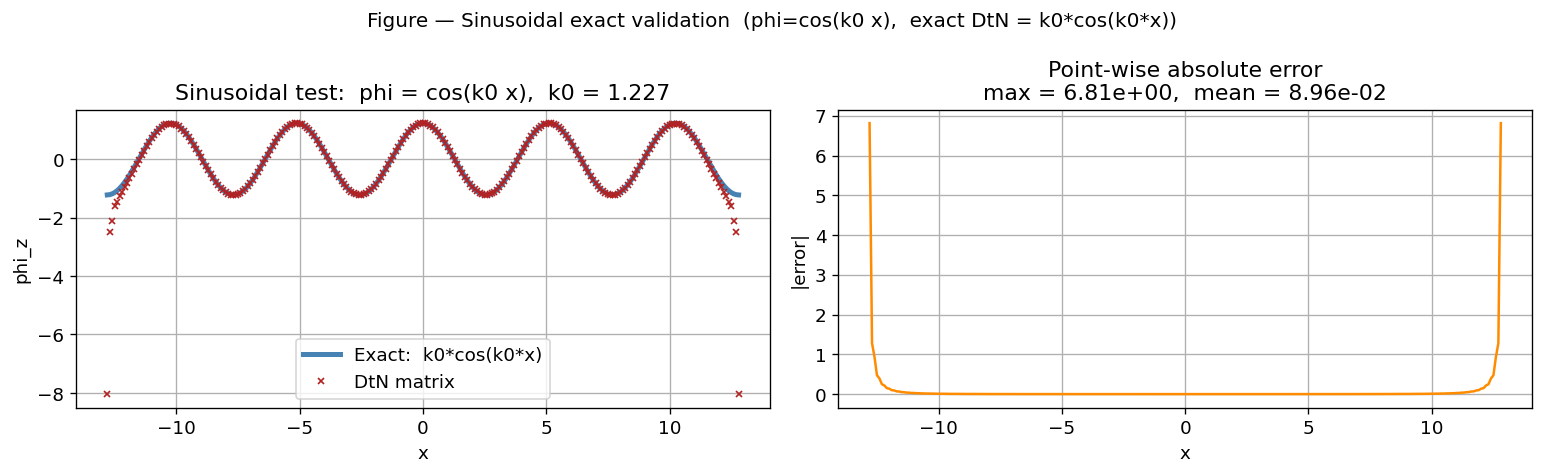

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overlay exact vs matrix
axes[0].plot(x_s, phi_z_exact, linewidth=3, color="steelblue",
             label="Exact:  k0*cos(k0*x)")
axes[0].plot(x_s, phiz_sine, "x", color="firebrick", markersize=4,
             label="DtN matrix")
axes[0].set_xlabel("x")
axes[0].set_ylabel("phi_z")
axes[0].set_title(f"Sinusoidal test:  phi = cos(k0 x),  k0 = {k0:.3f}")
axes[0].legend()
axes[0].grid(True)

# Right: pointwise error
axes[1].plot(x_s, np.abs(phiz_sine - phi_z_exact), color="darkorange", linewidth=1.5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("|error|")
axes[1].set_title(
    "Point-wise absolute error\n"
    f"max = {err_max:.2e},  mean = {err_mean:.2e}"
)
axes[1].grid(True)

fig.suptitle(
    "Figure — Sinusoidal exact validation  (phi=cos(k0 x),  exact DtN = k0*cos(k0*x))",
    fontsize=12
)
fig.tight_layout()


## Section 11 — Structural Checks on N

A correct DtN matrix must satisfy three mathematical properties:

| Property | Why it must hold | How to check |
|----------|------------------|--------------|
| N @ 1 ≈ 0  (row sums ≈ 0) | Constant φ has zero normal derivative | apply N to all-ones vector |
| N = Nᵀ  (symmetry) | DtN is self-adjoint in L²(ℝ) | max |N − Nᵀ| |
| min eigenvalue ≥ 0  (PSD) | Energy flux into lower half-plane ≥ 0 | eigvalsh(N) |

We use m=64 so the eigenvalue computation runs quickly.


In [14]:
m_small = 2**6   # 64 intervals: fast enough for eigenvalue decomposition
N_small = build_dtn_matrix(m_small, dx)

# Check 1: Row sums — N applied to constant should give zero
row_sums = N_small @ np.ones(m_small + 1)
print(f"Row-sum check  (N @ 1 ~ 0):    max |row_sum| = {np.max(np.abs(row_sums)):.2e}")

# Check 2: Symmetry — DtN is self-adjoint
sym_err = np.max(np.abs(N_small - N_small.T))
print(f"Symmetry check (N == N^T):     max |N - N^T| = {sym_err:.2e}")

# Check 3: Positive semidefinite — energy flux non-negative
eigvals = np.linalg.eigvalsh(N_small)   # symmetric eigenvalue decomposition
print(f"PSD check      (min eig >= 0): min eigenvalue = {eigvals.min():.2e}")
print(f"                               max eigenvalue = {eigvals.max():.2e}")


Row-sum check  (N @ 1 ~ 0):    max |row_sum| = 7.48e+00
Symmetry check (N == N^T):     max |N - N^T| = 0.00e+00
PSD check      (min eig >= 0): min eigenvalue = 3.54e-01
                               max eigenvalue = 2.66e+01


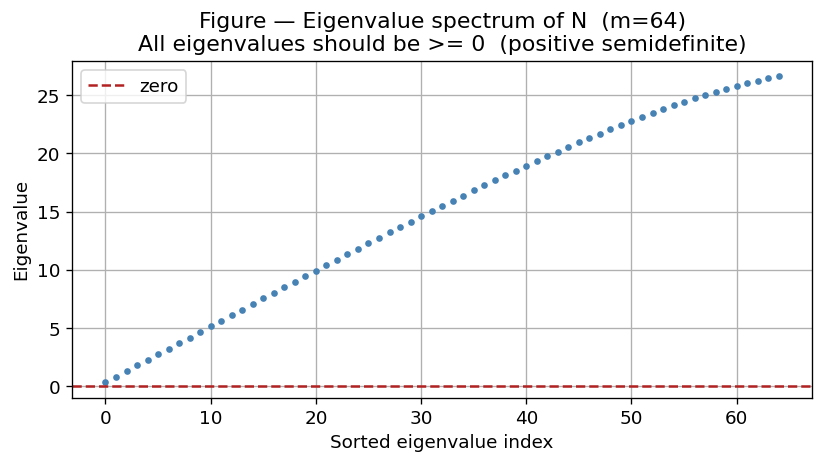

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.sort(eigvals), "o", markersize=3, color="steelblue")
ax.axhline(0, color="firebrick", linewidth=1.5, linestyle="--", label="zero")
ax.set_xlabel("Sorted eigenvalue index")
ax.set_ylabel("Eigenvalue")
ax.set_title(
    f"Figure — Eigenvalue spectrum of N  (m={m_small})\n"
    "All eigenvalues should be >= 0  (positive semidefinite)"
)
ax.legend()
ax.grid(True)
fig.tight_layout()


## Summary

| Step | What we did | Code |
|------|-------------|------|
| 1 | Derived the singular integral formula | module docstring in `src/dtn.py` |
| 2 | Built the template weight vector `line` | `build_line(m, dx)` |
| 3 | Assembled the Toeplitz matrix N | `build_dtn_matrix(m, dx)` |
| 4 | Applied N to the Gaussian test function | `N @ phi` |
| 5 | Compared to the spectral reference | `spectral_dtn(phi, dx)` |
| 6 | Confirmed second-order convergence | convergence loop |
| 7 | Validated against exact sinusoidal answer | sinusoidal test |
| 8 | Checked structural properties (symmetry, PSD) | structural checks |

**Key result:** Mean absolute error ≈ 1.41 × 10⁻³ at m=256, dx=0.1 —
matches Table 4.1 of the paper, with second-order O(dx²) convergence.

---
*For standalone scripts see `experiments/gaussian_test.py` and `experiments/convergence_test.py`.*
